In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

**Упражнение 1**

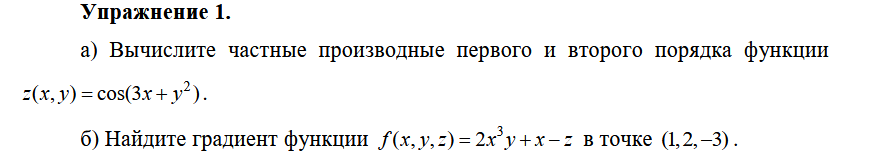

In [4]:
x, y, z = sp.symbols('x y z')

f_a = sp.cos(3*x + y**2)
dzdx = sp.diff(f_a, x)
dzdy = sp.diff(f_a, y)
d2zdx2 = sp.diff(f_a, x, 2)
d2zdy2 = sp.diff(f_a, y, 2)
d2zdxdy = sp.diff(f_a, x, y)

print("А) Частные производные:")
print(f"dz/dx: {dzdx}")
print(f"dz/dy: {dzdy}")
print(f"d2z/dx2: {d2zdx2}")
print(f"d2z/dy2: {d2zdy2}")
print(f"d2z/dxdy: {d2zdxdy}")

print()
print("Б) Градиент:")
f_b = 2*x**3*y + x - z
grad_f = [sp.diff(f_b, var) for var in (x, y, z)]
res_b = [g.subs({x: 1, y: 2, z: -3}) for g in grad_f]

print(f"Градиент в точке: {res_b}")

А) Частные производные:
dz/dx: -3*sin(3*x + y**2)
dz/dy: -2*y*sin(3*x + y**2)
d2z/dx2: -9*cos(3*x + y**2)
d2z/dy2: -2*(2*y**2*cos(3*x + y**2) + sin(3*x + y**2))
d2z/dxdy: -6*y*cos(3*x + y**2)

Б) Градиент:
Градиент в точке: [13, 2, -1]


**Упражнение 2**

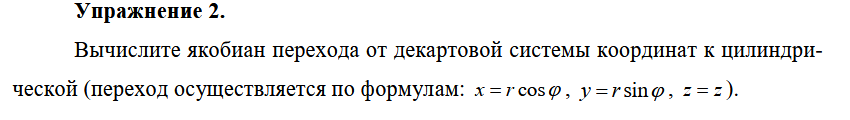

In [7]:
r, t, z = sp.symbols('r t z')
x = r * sp.cos(t)
y = r * sp.sin(t)
z = z
A = sp.Matrix([[x, y, z]])
B = sp.Matrix([[sp.diff(A,r)], [sp.diff(A,t)], [sp.diff(A,z)]])
sp.pprint(B.T)
sp.pprint(B.det())
sp.pprint(sp.simplify(B.det())) 

⎡cos(t)  -r⋅sin(t)  0⎤
⎢                    ⎥
⎢sin(t)  r⋅cos(t)   0⎥
⎢                    ⎥
⎣  0         0      1⎦
     2           2   
r⋅sin (t) + r⋅cos (t)
r


**Упражнение 3**

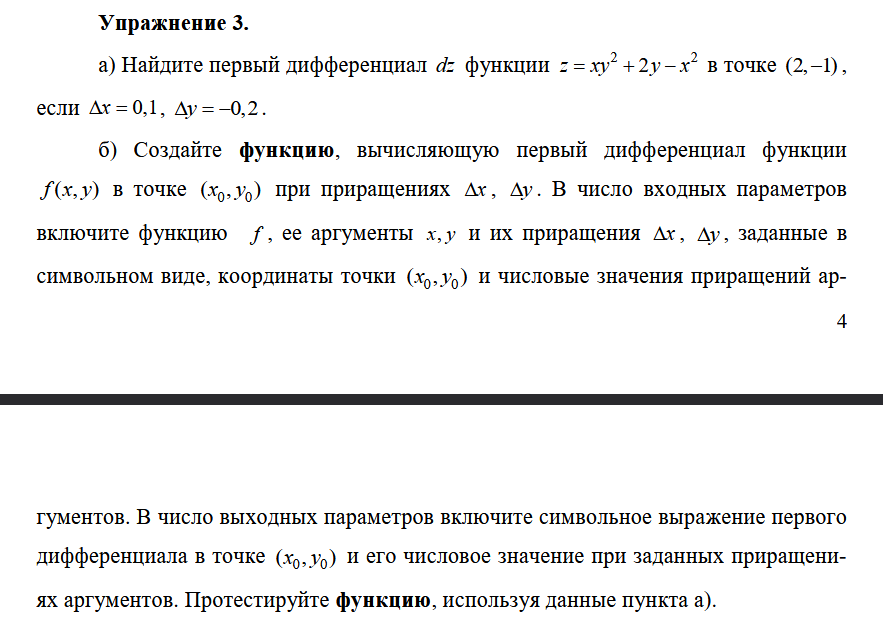

$z = xy^2+2y-x^2$

$\frac{\partial z}{\partial x} = y^2-2x = (-1)^2-2*2=-3$

$\frac{\partial z}{\partial y} = 2xy+2 = 2*2*(-1)+2=-2$

$dz = \frac{\partial z}{\partial x}*\Delta x + \frac{\partial z}{\partial y}*\Delta y = -3*0.1-2*(-0.2) = 0.1$

In [15]:
def calculate_differential(f_expr, x_sym, y_sym, dx_sym, dy_sym, x0, y0, dx_val, dy_val):
    df_dx = sp.diff(f_expr, x_sym)
    df_dy = sp.diff(f_expr, y_sym)

    dz_symbolic = df_dx * dx_sym + df_dy * dy_sym
    dz_at_point = dz_symbolic.subs({x_sym: x0, y_sym: y0})
    dz_numeric = dz_at_point.subs({dx_sym: dx_val, dy_sym: dy_val})    
    
    return dz_at_point, dz_numeric


x, y = sp.symbols('x y')
dx, dy = sp.symbols('dx dy')

f = x * y**2 + 2 * y - x**2
point = (2, -1)
deltas = (0.1, -0.2)

dz_expr, dz_val = calculate_differential(f, x, y, dx, dy, *point, *deltas)

sp.pprint(dz_expr)
print(dz_val)

-3⋅dx - 2⋅dy
0.100000000000000


**Упражнение 4**

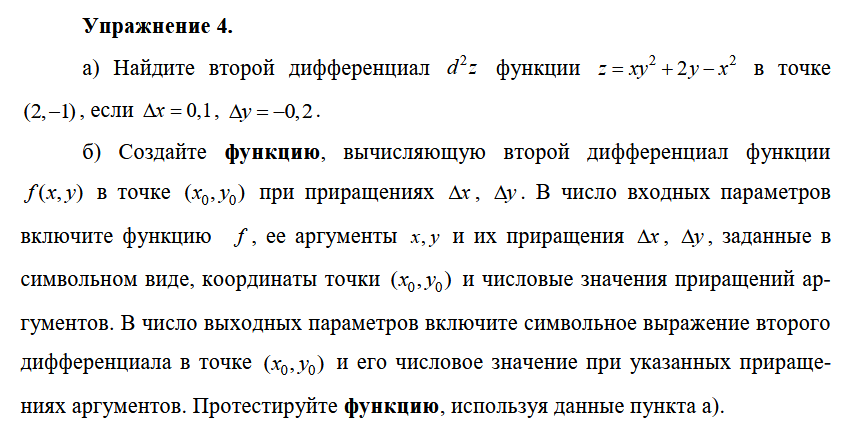

$z = xy^2+2y-x^2$

$\frac{\partial z}{\partial x} = y^2-2x$

$\frac{\partial z}{\partial y} = 2xy+2$

$\frac{\delta^2 z}{\delta x \delta y} = 2*y = 2*(-1) = -2$

$\frac{\delta^2 z}{\delta^2 x} = -2$

$\frac{\delta^2 z}{\delta^2 y} = 2*x=2*2=4$

$d^2z = \frac{\delta^2 z}{\delta^2 x}*(\Delta x)^2 + 2*\frac{\delta^2 z}{\delta x \delta y}*\Delta x * \Delta y + \frac{\delta^2 z}{\delta^2 y}* (\Delta y)^2 =$

$= -2*(0.1)^2-4*0.1*(-0.2)+4*(-0.2)^2 = 0.22$

In [14]:
import sympy as sp

def calculate_second_differential(f_expr, x_sym, y_sym, dx_sym, dy_sym, x0, y0, dx_val, dy_val):
    fxx = sp.diff(f_expr, x_sym, 2)
    fyy = sp.diff(f_expr, y_sym, 2)
    fxy = sp.diff(f_expr, x_sym, y_sym)

    d2z_symbolic = fxx * dx_sym**2 + 2 * fxy * dx_sym * dy_sym + fyy * dy_sym**2
    d2z_at_point = d2z_symbolic.subs({x_sym: x0, y_sym: y0})
    d2z_numeric = d2z_at_point.subs({dx_sym: dx_val, dy_sym: dy_val})
    
    return d2z_at_point, d2z_numeric


x, y = sp.symbols('x y')
dx, dy = sp.symbols('dx dy')

f = x * y**2 + 2 * y - x**2
point = (2, -1)
deltas = (0.1, -0.2)

d2z_expr, d2z_val = calculate_second_differential(
    f, x, y, dx, dy, 
    point[0], point[1], 
    deltas[0], deltas[1]
)

sp.pprint(d2z_expr)
print(d2z_val)

      2                 2
- 2⋅dx  - 4⋅dx⋅dy + 4⋅dy 
0.220000000000000


**Упражнение 5**

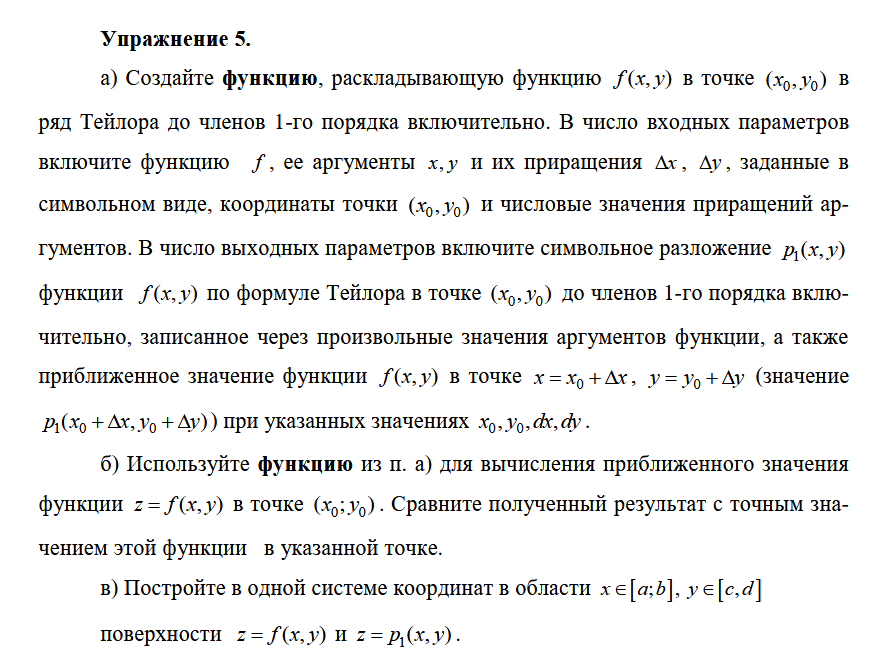

Разложение p1(x, y): -3*x - 2*y
Приближенное значение: -3.90000000000000
Точное значение: -3.78600000000000
Погрешность: 0.114000000000000


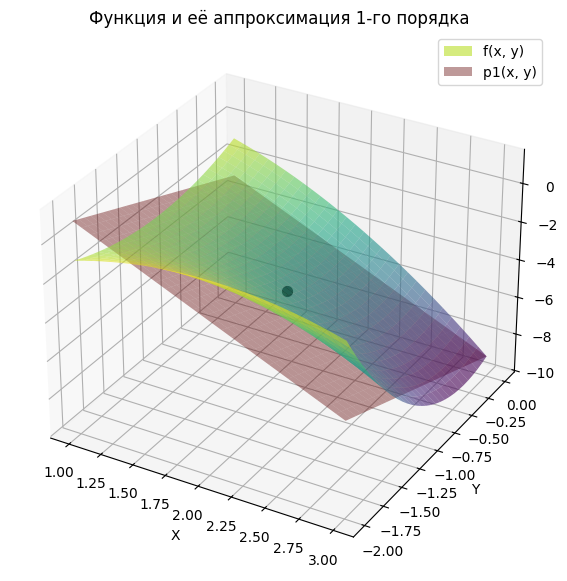

In [17]:
def taylor_first_order(f_expr, x_sym, y_sym, x0, y0, dx_val, dy_val):
    f_at_point = f_expr.subs({x_sym: x0, y_sym: y0})
    
    df_dx_val = sp.diff(f_expr, x_sym).subs({x_sym: x0, y_sym: y0})
    df_dy_val = sp.diff(f_expr, y_sym).subs({x_sym: x0, y_sym: y0})
    
    p1_expr = f_at_point + df_dx_val * (x_sym - x0) + df_dy_val * (y_sym - y0)
    approx_val = p1_expr.subs({x_sym: x0 + dx_val, y_sym: y0 + dy_val})
    
    return p1_expr, approx_val

x, y = sp.symbols('x y')
f = x * y**2 + 2 * y - x**2
x0, y0 = 2, -1
dx, dy = 0.1, -0.2

p1_sym, p1_num = taylor_first_order(f, x, y, x0, y0, dx, dy)
exact_val = f.subs({x: x0 + dx, y: y0 + dy})

print(f"Разложение p1(x, y): {p1_sym}")
print(f"Приближенное значение: {p1_num}")
print(f"Точное значение: {exact_val.evalf()}")
print(f"Погрешность: {abs(exact_val - p1_num).evalf()}")

f_func = sp.lambdify((x, y), f, 'numpy')
p1_func = sp.lambdify((x, y), p1_sym, 'numpy')

x_range = np.linspace(x0 - 1, x0 + 1, 30)
y_range = np.linspace(y0 - 1, y0 + 1, 30)
X, Y = np.meshgrid(x_range, y_range)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, f_func(X, Y), alpha=0.6, cmap='viridis', label='f(x, y)')
ax.plot_surface(X, Y, p1_func(X, Y), alpha=0.4, color='red', label='p1(x, y)')
ax.scatter([x0], [y0], [float(f.subs({x: x0, y: y0}))], color='black', s=50)

ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
plt.title("Функция и её аппроксимация 1-го порядка")
plt.legend()
plt.show()

**Упражнение 6**

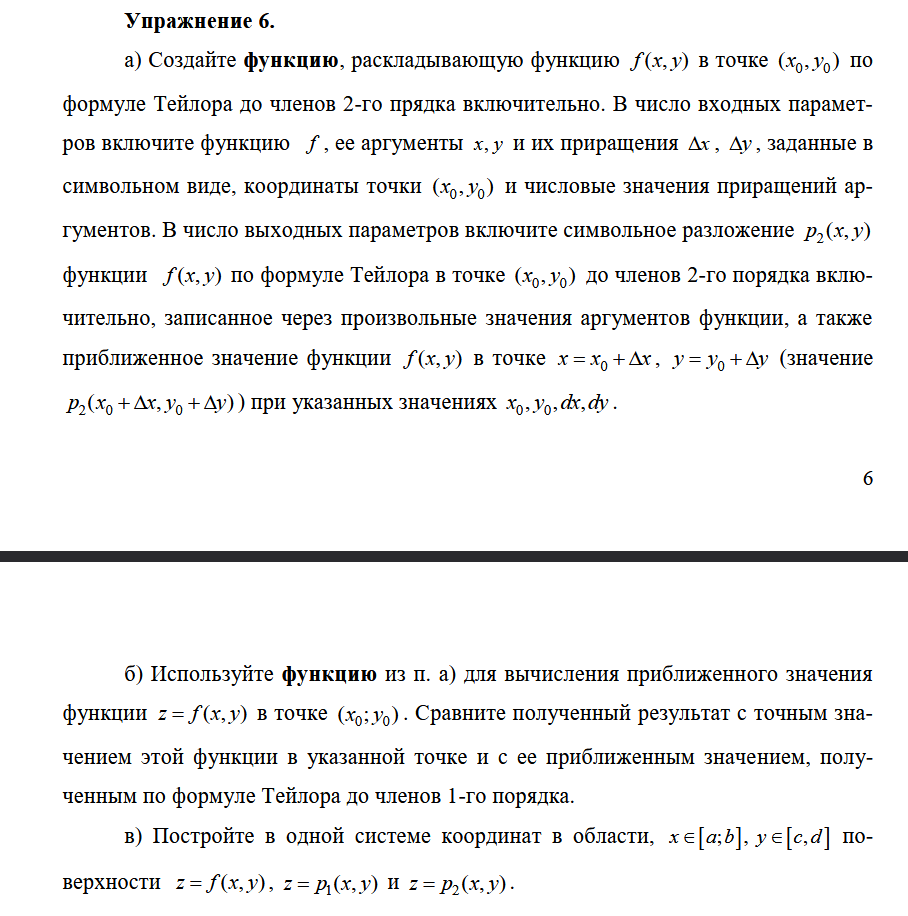

Точное значение: -3.78600000000000
p1 (линейное): -3.90000000000000, ошибка: 0.114000000000000
p2 (квадратичное): -3.79000000000000, ошибка: 0.00400000000000000


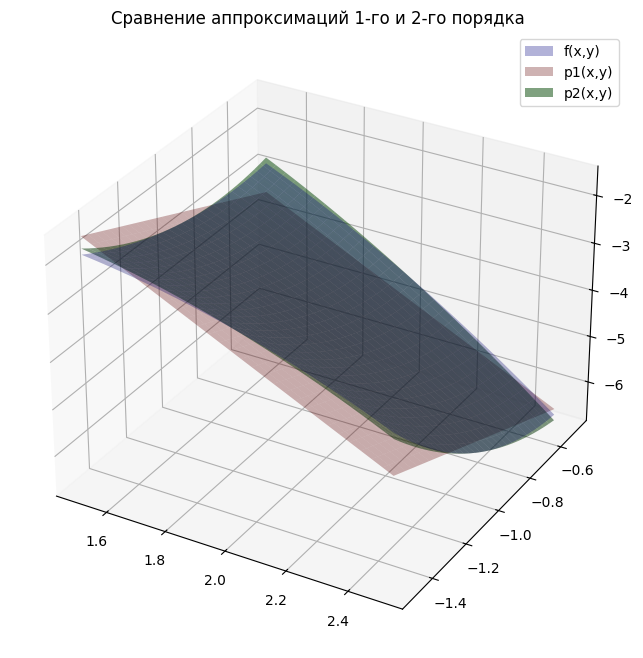

In [ ]:
def taylor_second_order(f_expr, x_sym, y_sym, x0, y0, dx_val, dy_val):
    f0 = f_expr.subs({x_sym: x0, y_sym: y0})

    fx = sp.diff(f_expr, x_sym).subs({x_sym: x0, y_sym: y0})
    fy = sp.diff(f_expr, y_sym).subs({x_sym: x0, y_sym: y0})
    
    fxx = sp.diff(f_expr, x_sym, 2).subs({x_sym: x0, y_sym: y0})
    fyy = sp.diff(f_expr, y_sym, 2).subs({x_sym: x0, y_sym: y0})
    fxy = sp.diff(f_expr, x_sym, y_sym).subs({x_sym: x0, y_sym: y0})
    
    dx = x_sym - x0
    dy = y_sym - y0
    p2_expr = f0 + (fx*dx + fy*dy) + 0.5*(fxx*dx**2 + 2*fxy*dx*dy + fyy*dy**2)
    
    approx_val = p2_expr.subs({x_sym: x0 + dx_val, y_sym: y0 + dy_val})
    
    return p2_expr, approx_val

x, y = sp.symbols('x y')
f = x * y**2 + 2 * y - x**2
x0, y0, dx, dy = 2, -1, 0.1, -0.2

p1_expr, p1_val = taylor_first_order(f, x, y, x0, y0, dx, dy)
p2_expr, p2_val = taylor_second_order(f, x, y, x0, y0, dx, dy)
exact_val = f.subs({x: x0 + dx, y: y0 + dy}).evalf()

print(f"Точное значение: {exact_val}")
print(f"p1 (линейное): {p1_val.evalf()}, ошибка: {abs(exact_val - p1_val).evalf()}")
print(f"p2 (квадратичное): {p2_val.evalf()}, ошибка: {abs(exact_val - p2_val).evalf()}")

f_np = sp.lambdify((x, y), f, 'numpy')
p1_np = sp.lambdify((x, y), p1_expr, 'numpy')
p2_np = sp.lambdify((x, y), p2_expr, 'numpy')

X_vals = np.linspace(x0 - 0.5, x0 + 0.5, 30)
Y_vals = np.linspace(y0 - 0.5, y0 + 0.5, 30)
X, Y = np.meshgrid(X_vals, Y_vals)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, f_np(X, Y), alpha=0.3, color='blue', label='f(x,y)')
ax.plot_surface(X, Y, p1_np(X, Y), alpha=0.3, color='red', label='p1(x,y)')
ax.plot_surface(X, Y, p2_np(X, Y), alpha=0.5, color='green', label='p2(x,y)')

ax.set_title("Сравнение аппроксимаций 1-го и 2-го порядка")
plt.legend()
plt.show()